#                                    Langchain basic part2 

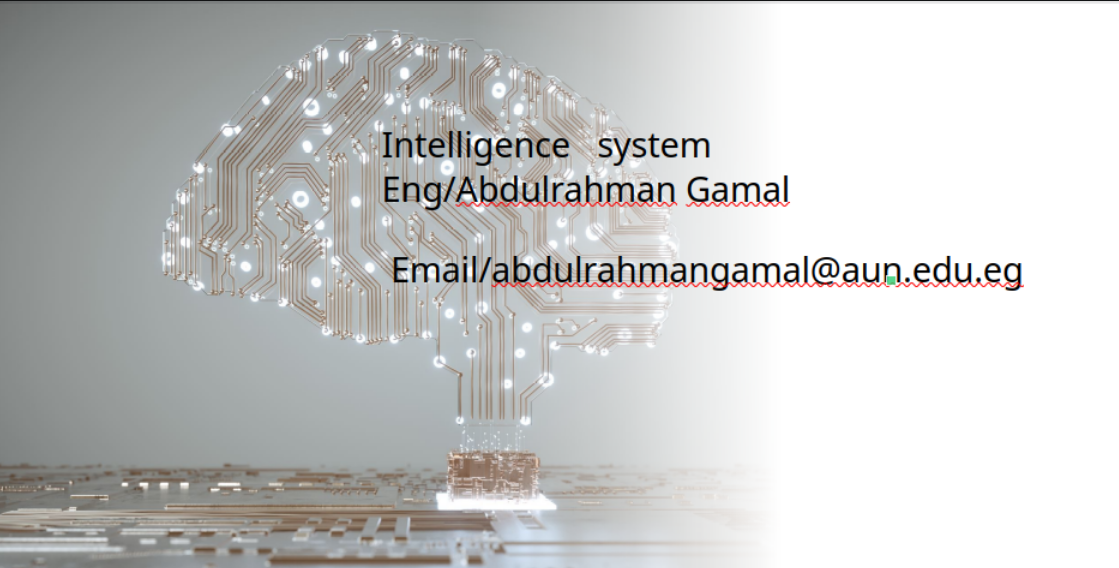

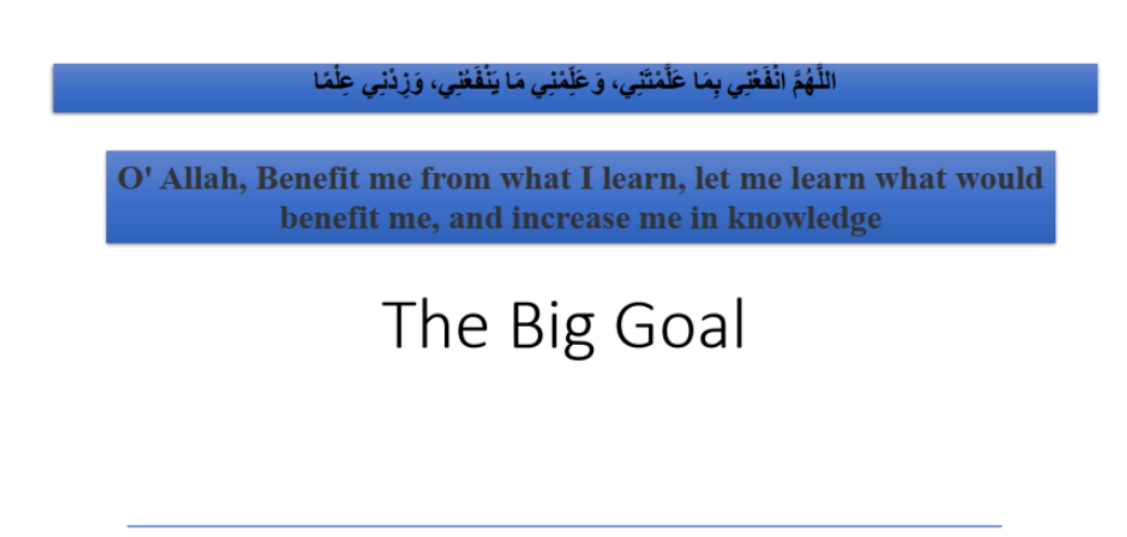

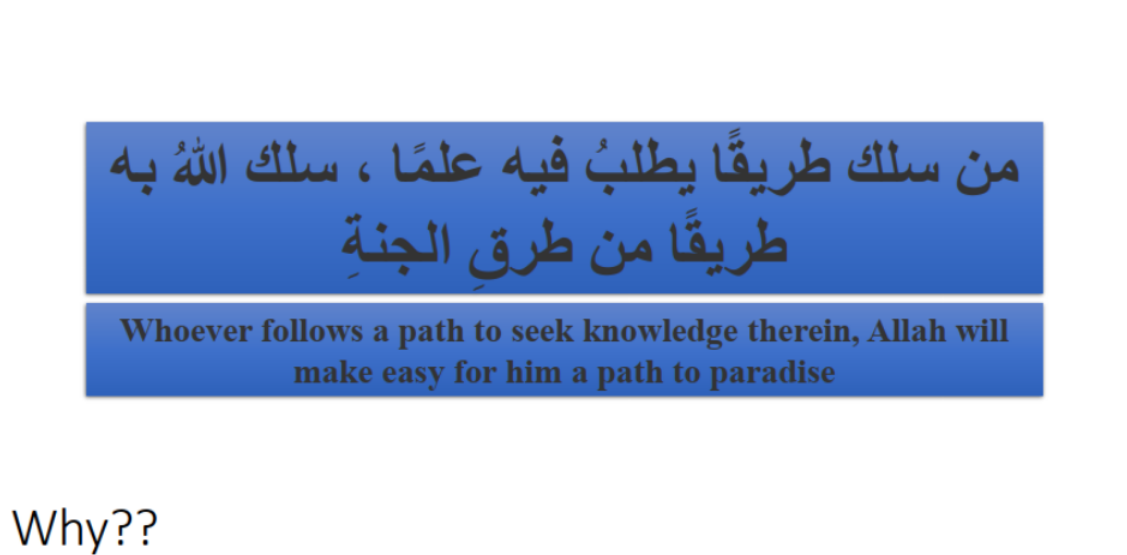

# chain 

In this section you will master the concept of chains and also the lang chain expression language.

Lang chain provides a declarative way to sequentially execute the prompt and the LLM objects.

The syntax we use for this is called the lang chain expression language.
We separate out the prompt and the LLM using the pipe symbol.


## Old example without chain 


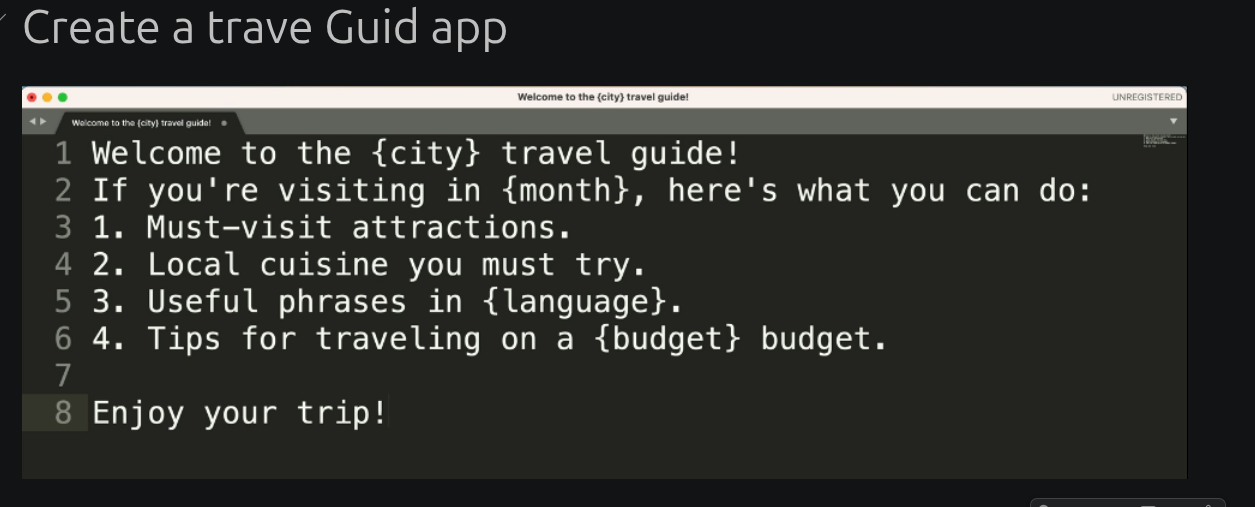

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate
prompt_template = PromptTemplate(
    input_variables=["city","month","language","budget"],
    template="""Welcome to the {city} travel guide!
    If you're visiting in {month}, here's what you can do:
    1. Must-visit attractions.
    2. Local cuisine you must try.
    3. Useful phrases in {language}.
    4. Tips for traveling on a {budget} budget.
    Enjoy your trip!
    """
)

import streamlit as st

st.title("Travel Guide")

city = st.text_input("Enter the city:")
month = st.text_input("Enter the month of travel")
language = st.text_input("Enter the language:")
budget = st.selectbox("Travel Budget",["Low","Medium","High"])


if city and month and language and budget:
    response = llm.invoke(prompt_template.format(city=city,
                                                 month=month,
                                                 language=language,
                                                 budget=budget
                                                 ))
    st.write(response.content)

## New example with chain ?

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate
prompt_template = PromptTemplate(
    input_variables=["city","month","language","budget"],
    template="""Welcome to the {city} travel guide!
    If you're visiting in {month}, here's what you can do:
    1. Must-visit attractions.
    2. Local cuisine you must try.
    3. Useful phrases in {language}.
    4. Tips for traveling on a {budget} budget.
    Enjoy your trip!
    """
)

import streamlit as st
st.title("Travel Guide")

city = st.text_input("Enter the city:")
month = st.text_input("Enter the month of travel")
language = st.text_input("Enter the language:")
budget = st.selectbox("Travel Budget",["Low","Medium","High"])


chain = prompt_template | llm

if city and month and language and budget:
    response = chain.invoke({"city":city,
                             "month":month,
                             "language":language,
                             "budget":budget
                             })
    
    st.write(response.content)

chain = prompt_template | llm

Internally, this chain is represented as an object of the following type in lang chain 

langchain_core_Runnables_base_runnablesequence class 

so lang chain will create a object of this type to represent this chain,   
 and it will execute this sequence for us, where the prompt template will be passed to the LLM and we get the required output.




In [2]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.31.81.214:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1590, in _shutdown
    lock.acquire()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/streamlit/web/server/server.py", line 550, in stop
    self._runtime.stop()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/streamlit/runtime/runtime.py", line 351, in stop
    async_objs.eventloop.call_soon_threadsafe(stop_on_eventlo

## type of chain 

 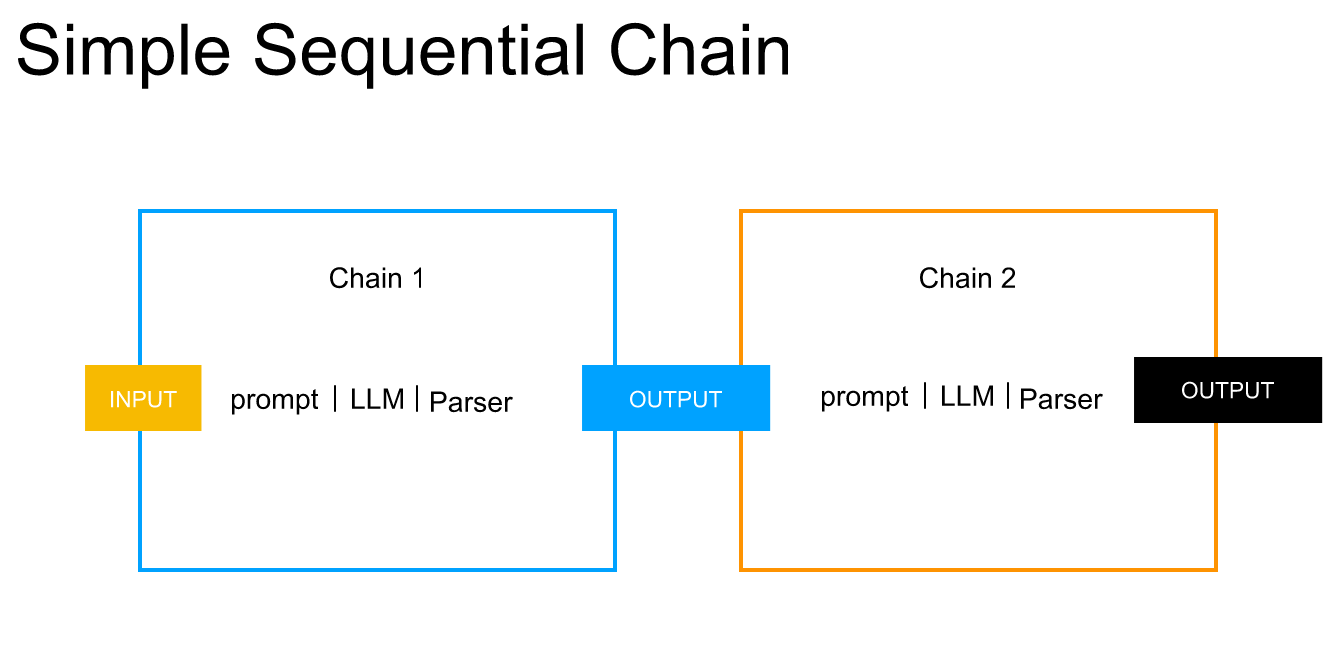

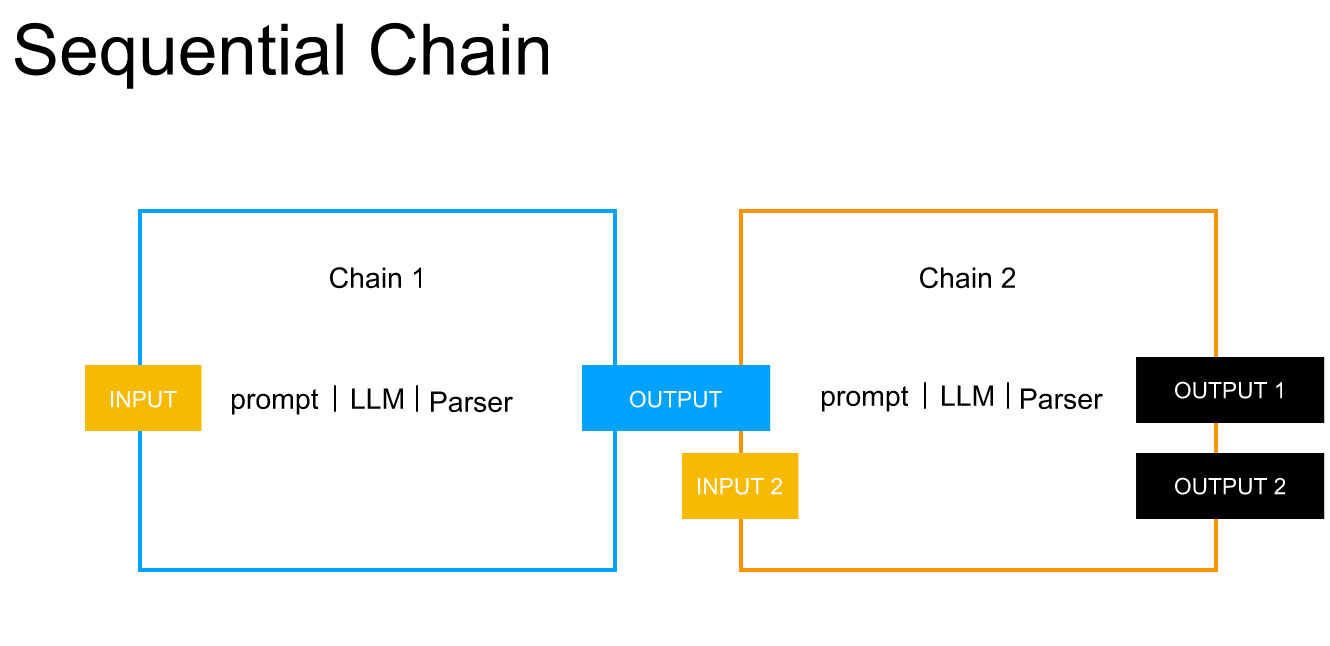

the seconad chain take two input and make  two output

## Example on simple chain 

make two chain   make output from firt one  as input to seconad one 

first chain generate title  second  one generate  speech

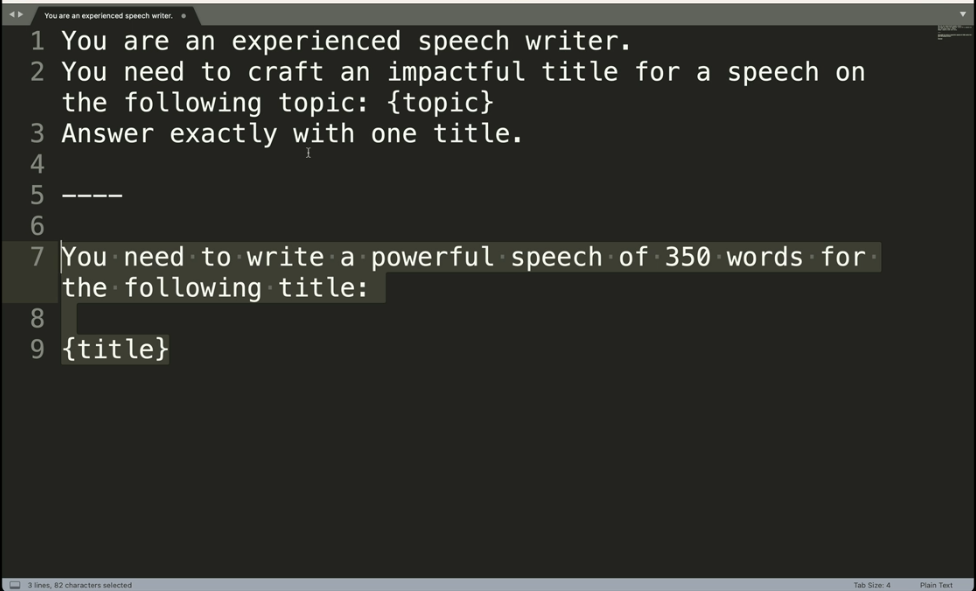

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_core.output_parsers import StrOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate

title_prompt = PromptTemplate(
    input_variables=["topic"],
    template="""You are an experienced speech writer.
    You need to craft an impactful title for a speech 
    on the following topic: {topic}
    Answer exactly with one title.	
    """
)

speech_prompt = PromptTemplate(
    input_variables=["title"],
    template="""You need to write a powerful speech of 50 words
     for the following title: {title}
    """
)

first_chain = title_prompt | llm | StrOutputParser() 
second_chain = speech_prompt | llm
final_chain = first_chain | second_chain

import streamlit as st
st.title("Speech Generator")

topic = st.text_input("Enter the topic:")

if topic:
    response = final_chain.invoke({"topic":topic})
    st.write(response.content)

StrOutputParser()

It will retrieve the ` content ` portion of the response if it has it, and it will return it back.

content is the title

In [3]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.3:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/env

### Note do not show  the title 

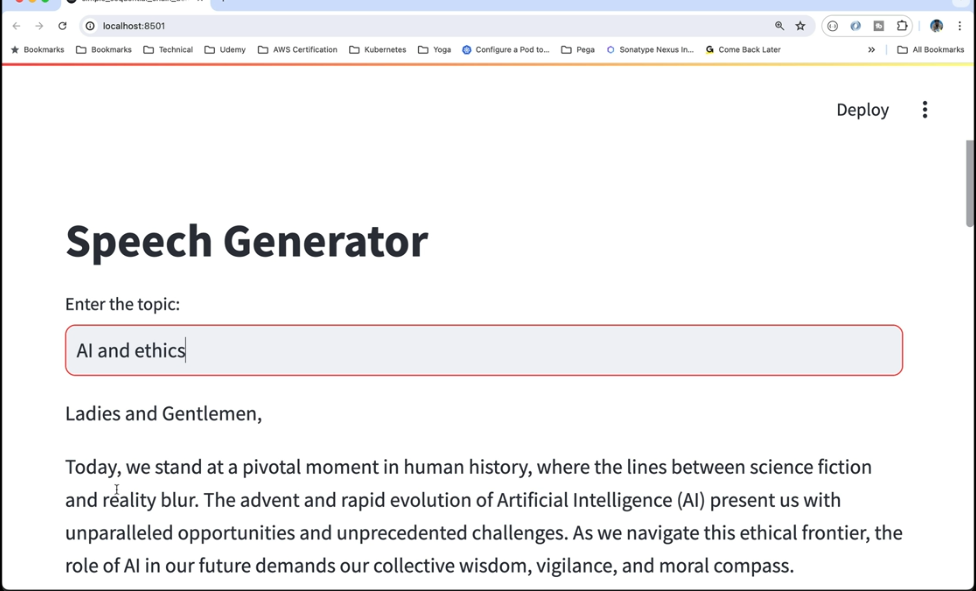

## Display title with lambda 

The string output parser will return the title, which is being passed to the second chain.

So right here we need to extract that and print it onto the web browser.And also we need    
to make sure that that title again will be passed to the second chain.

We have two responsibilities.

(lambda title: (st.write(title),title)[1])

The first element in this tuple is Streamlit.write ,print title on streamlit      
The second element is the title itself, we return it as output of lambda   by select index  one      


In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_core.output_parsers import StrOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate

title_prompt = PromptTemplate(
    input_variables=["topic"],
    template="""You are an experienced speech writer.
    You need to craft an impactful title for a speech 
    on the following topic: {topic}
    Answer exactly with one title.	
    """
)

speech_prompt = PromptTemplate(
    input_variables=["title"],
    template="""You need to write a powerful speech of 50 words
     for the following title: {title}
    """
)

first_chain = title_prompt | llm | StrOutputParser() | (lambda title: (st.write(title),title)[1])
second_chain = speech_prompt | llm
final_chain = first_chain | second_chain

import streamlit as st
st.title("Speech Generator")

topic = st.text_input("Enter the topic:")

if topic:
    response = final_chain.invoke({"topic":topic})
    st.write(response.content)

In [4]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.3:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/env

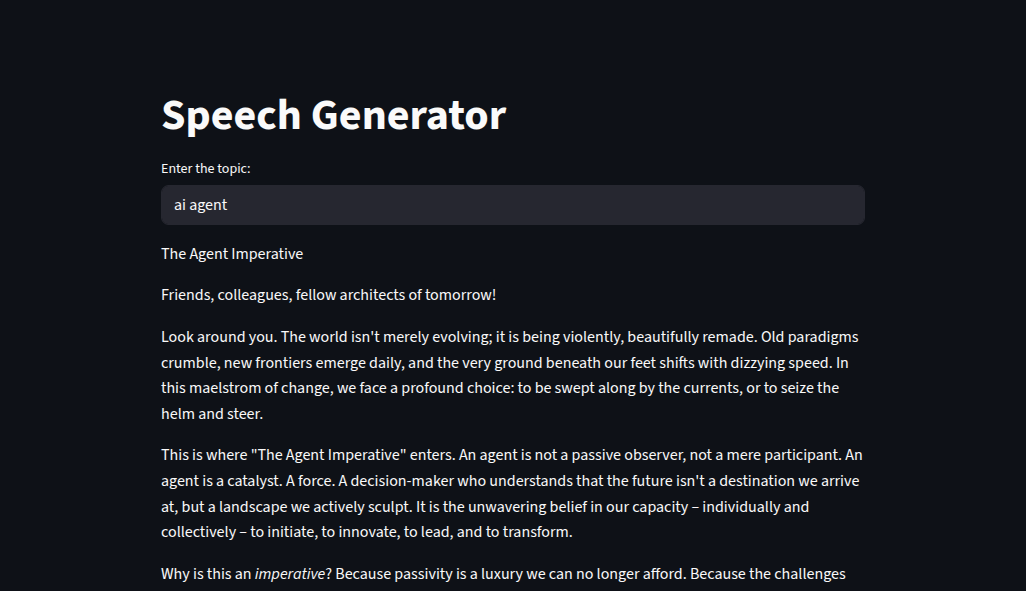

# Note that you can make two different  model, one for each chain 

in this screen i use  mistral model for first chain  and   chatgpt  model for second chain ,

only chaining  the first line  rest of  the code is the same .

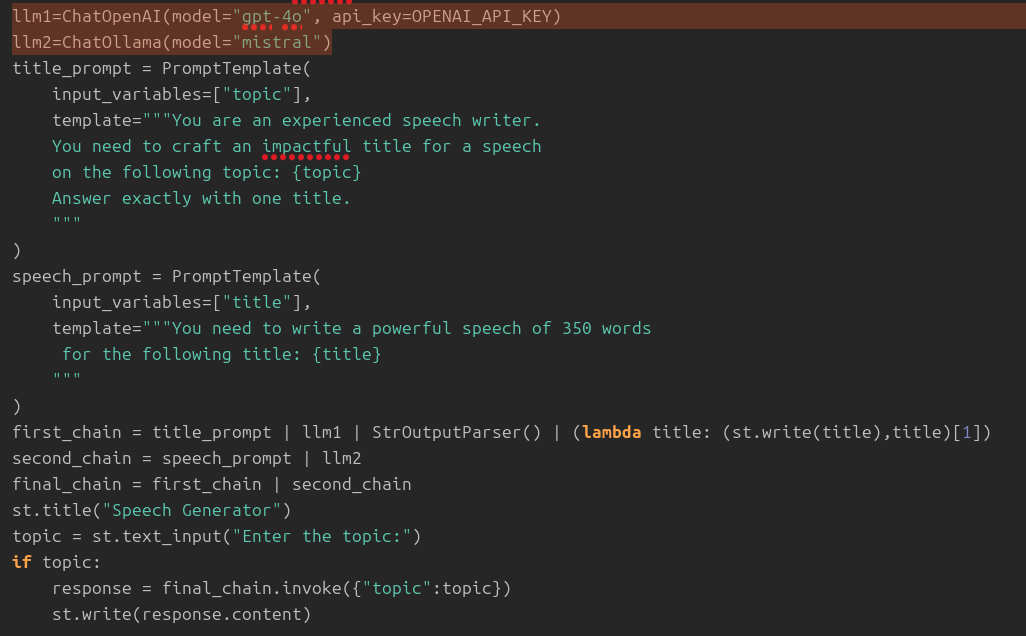

## Regular sequential chain or sequential chain

In this section  you will see regular sequential chain or sequential chain in action.

need change second prompt  to tak  two input  `title and motion `


In [ ]:
from langchain_core.prompts import PromptTemplate


import os
from dotenv import load_dotenv
load_dotenv()
from langchain_core.output_parsers import StrOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate

title_prompt = PromptTemplate(
    input_variables=["topic"],
    template="""You are an experienced speech writer.
    You need to craft an impactful title for a speech 
    on the following topic: {topic}
    Answer exactly with one title.	
    """
)

speech_prompt = PromptTemplate(
    input_variables=["title", "emotion"],
    template="""You need to write a powerful {emotion} speech of 50 words
     for the following title: {title}   
    """
)

topic = st.text_input("Enter the topic:")
emotion = st.text_input("Enter the emotion:")

first_chain = title_prompt | llm | StrOutputParser() | (lambda title: (st.write(title),title)[1])
second_chain = speech_prompt | llm
final_chain = first_chain | (lambda title:{"title": title,"emotion": emotion}) | second_chain

import streamlit as st
st.title("Speech Generator")

if topic and emotion:
    response = final_chain.invoke({"topic":topic})
    st.write(response.content)


In [4]:
x=1
def test():
    print(x+1)
test()  

2


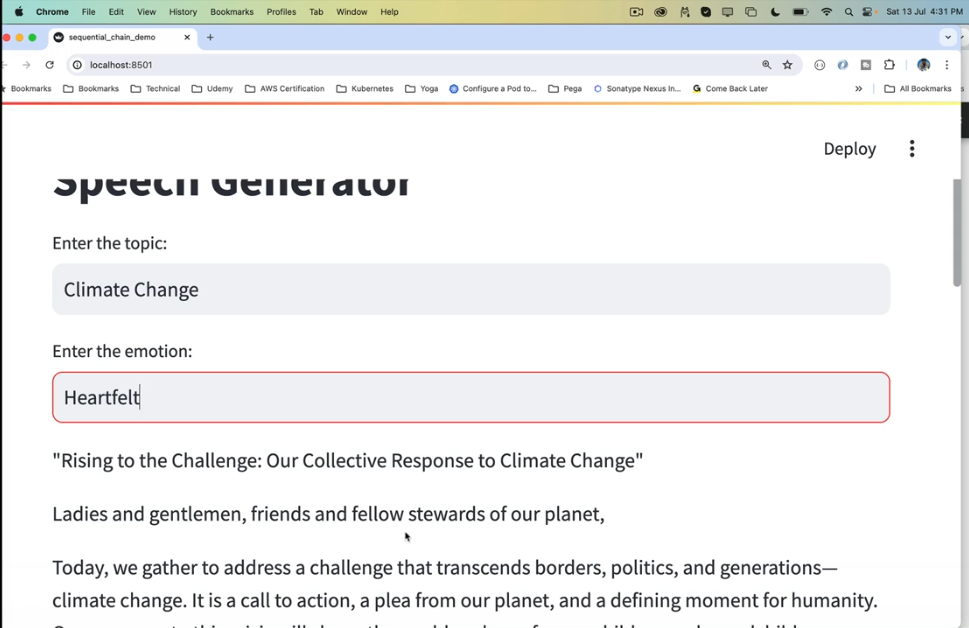

In [7]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.3:8501

2026-04-27 17:36:58.367 Uncaught app execution
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/langchain_google_genai/chat_models.py", line 3071, in _generate
    response: GenerateContentResponse = self.client.models.generate_content(
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrah

## Foramt the output

In this lecture, you will see how we can add more to the final output of the chain, or how we can
manipulate the output format, and how the chain will keep track of all that.

need the final ouput json format  to pass it to another app  use `JsonOutputParser`    
, change second  prompt   also ,and change the output line 

In [ ]:
from langchain_core.prompts import PromptTemplate


import os
from dotenv import load_dotenv
load_dotenv()

# add this import for JsonOutputParser
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

from langchain_core.prompts import PromptTemplate
title_prompt = PromptTemplate(
    input_variables=["topic"],
    template="""You are an experienced speech writer.
    You need to craft an impactful title for a speech 
    on the following topic: {topic}
    Answer exactly with one title.	
    """
)
# make chainge  here  add this " format the output as JSON with keys "title" and "speech"   "
speech_prompt = PromptTemplate(
    input_variables=["title", "emotion"],
    template="""You need to write a powerful {emotion} speech of 50 words
     for the following title: {title}   
     format the output as JSON with keys "title" and "speech" and fill
    them with the title and the speech  value respectively.

    """
)

# do not need to write the title to the streamlit app since we will get it in the final output as JSON now
first_chain = title_prompt | llm | StrOutputParser() 
second_chain = speech_prompt | llm | JsonOutputParser()
final_chain = first_chain | (lambda title:{"title": title,"emotion": emotion}) | second_chain

import streamlit as st
st.title("Speech Generator")

topic = st.text_input("Enter the topic:")
emotion = st.text_input("Enter the emotion:")
submit_button = st.button("Generate Speech")

if topic and emotion and submit_button:
    response = final_chain.invoke({"topic":topic})
    st.write(response['title']) 
    # change here to response.content since we are using JsonOutputParser now
    st.write(response['speech']) 





2026-04-27 18:02:59.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.034 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.045 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.049 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.066 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-27 18:02:59.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

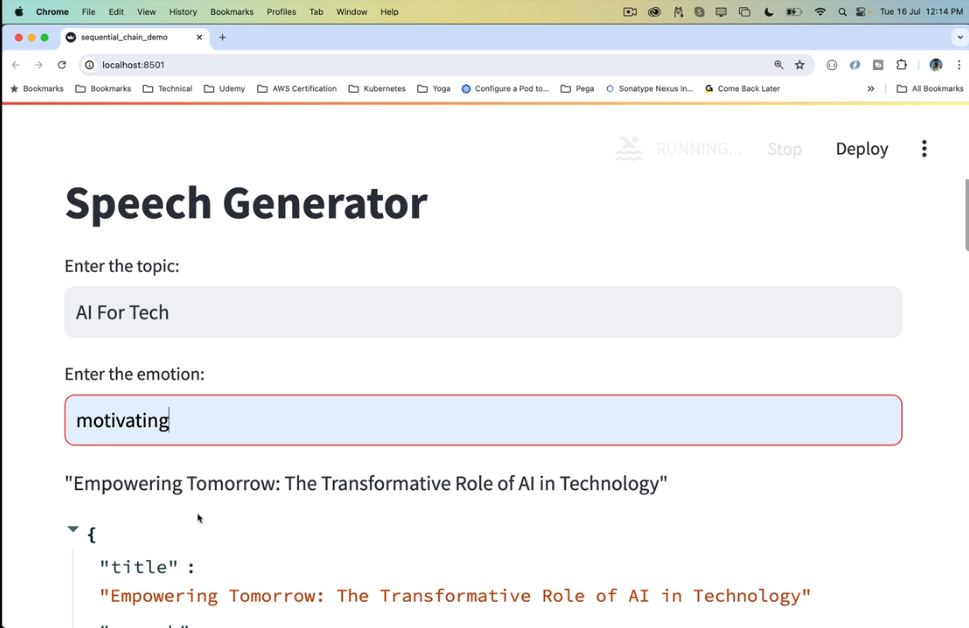

In [16]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.3:8501

2026-04-27 18:39:25.448 Uncaught app execution
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/langchain_google_genai/chat_models.py", line 3071, in _generate
    response: GenerateContentResponse = self.client.models.generate_content(
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrah

## Chat Massege promote 

افرض مثلا يعنى انك عامل موقع للسياحه   وواحد دخل الموقع وسئل سوال   زى  
ايه هو الزكاء الاصطناعى 
مفروض  هيطلعه اجابه فهو كده استغل اشتراك  
فاحنا محتاجين  بس حاجه تقول للمودل بتاعى  او الموظ هو مين وبيعمل ايه  



You will start by learning how to use the chart prompt template.
So far, we have used the prompt template that allowed us to send in the prompt text.
The chart prompt template allows us to specify roles within the prompt.

The system role tells the model how it should behave.
So using the system role, whatever message you send that tells the model how it should behave.


In [ ]:
import os , time 
from dotenv import load_dotenv
load_dotenv()
from langchain_core.output_parsers import StrOutputParser

from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")





from langchain_core.prompts import ChatPromptTemplate
prompt_template = ChatPromptTemplate.from_messages(
[
    ("system","You are a Agile Coach.Answer any questions "
              "related to the agile process"),
    ("human", "{input}")
]
)

import streamlit as st
st.title("Agile Guide")

input = st.text_input("Enter the question:")
bott=st.button("Get Answer")

chain = prompt_template | llm

if input and bott:
    response = chain.invoke({"input":input})
    st.write(response.content)
    time.sleep(60)

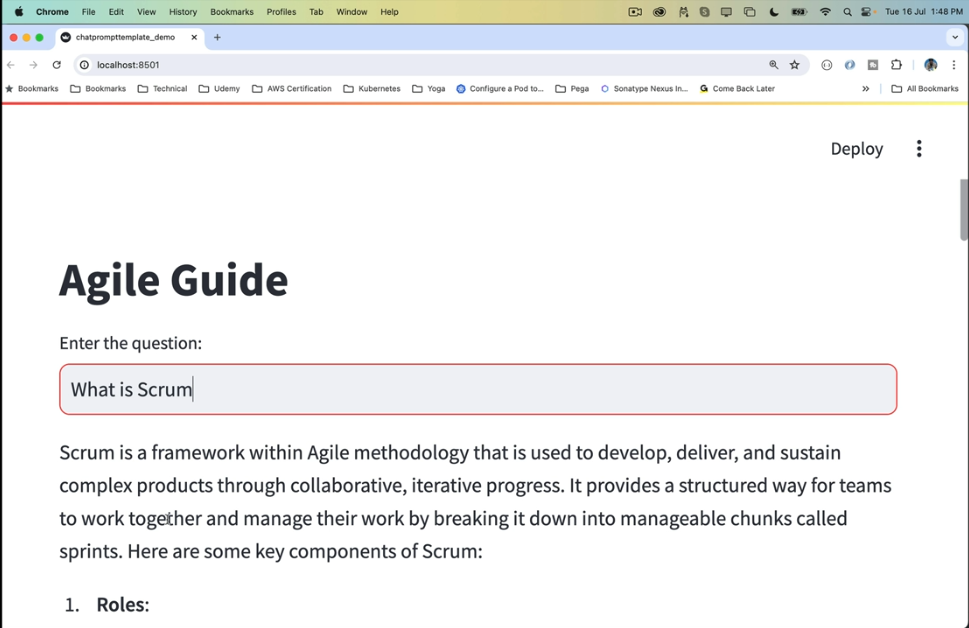

In [20]:
! streamlit run test_code.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.3:8501

2026-04-27 19:24:29.256 Uncaught app execution
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/langchain_google_genai/chat_models.py", line 3071, in _generate
    response: GenerateContentResponse = self.client.models.generate_content(
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrah

# LangSmith 



In this section, 

you will learn how to use Lang Smith, a powerful observability and testing tool designed for AI workflows built using Lang Chain and Lang graph.

So Lang Smith automatically integrates with the Lang chain applications and Landgraf workflows.

It knows the renewables that run inside a workflow, and it will automatically trace them for us.



### Setup Langsmith  

`two thing   1-create key ,  2-set four environment variables `


To start using LangSmith we need to set three environment variables:

• LANGSMITH_TRACING

Enables request tracing so all LangChain and agent executions are logged and visualized in LangSmith for debugging and performance analysis.

• LANGSMITH_API_KEY

Authenticates your application with LangSmith so traces, runs, and metadata can be securely sent to your LangSmith account.

• LANGSMITH_PROJECT

Groups all traces under a named project in LangSmith, making it easy to organize, filter, and analyze experiments and demos   
 (for example, langchaindemo).

• LANGSMITH_ENDPOINT=https://eu.api.smith.langchain.com


`api key langsmith`

link: https://smith.langchain.com 


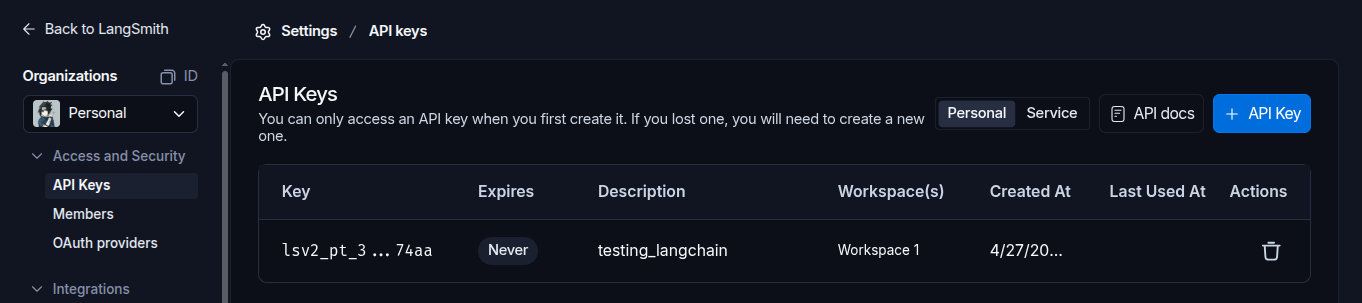

` three env variable ` 

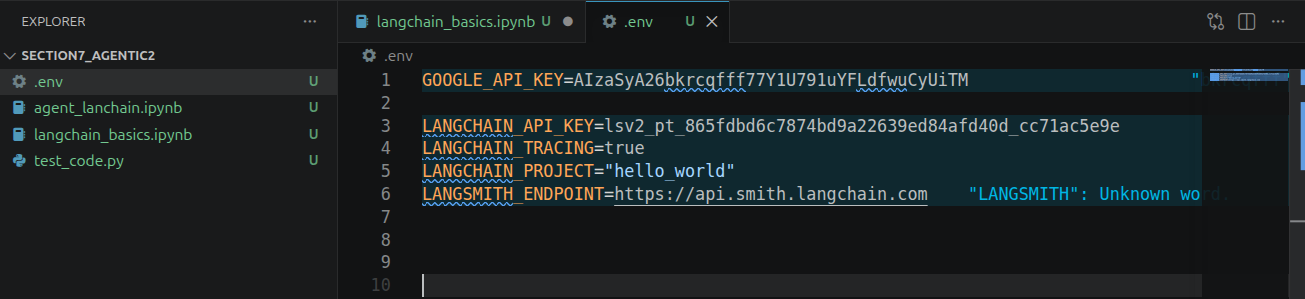

In [4]:
import os
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama 

load_dotenv()

llm = ChatOllama(model="gemma:2b")

prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", "You are an Agile Coach. Answer any questions related to the agile process"),
        ("human", "{input}")
    ]
)
chain = prompt_template | llm 

print("=== Agile Guide (Terminal Version) ===")


user_input = "what is ai in one sentence? "

if user_input:
    response = chain.invoke({"input": user_input})
    
    print("\nAgile Coach:")
    print(response.content)
    print("-" * 40)

=== Agile Guide (Terminal Version) ===

Agile Coach:
Sure. Here's a one-sentence summary of Agile:

Agile is a project management framework that emphasizes iterative and collaborative development, allowing teams to continuously learn and adapt based on feedback.
----------------------------------------


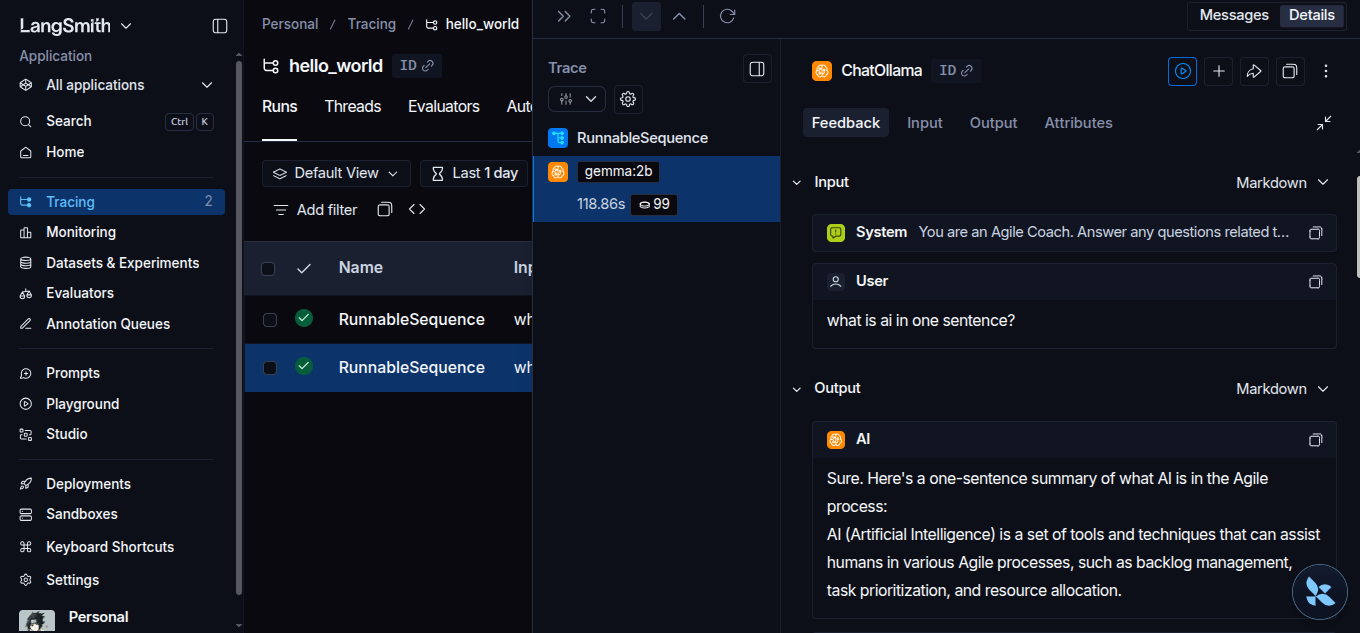

# Reference



1-Langchain for beginners : Build GenAI LLM Apps in Easy Steps 

https://banquemisr25.udemy.com/course/langchain-for-beginners-build-genai-llm-apps-in-easy-steps/learn/lecture/44753827#overview   



2- LangChain- Agentic AI Engineering with LangChain & LangGraph

https://banquemisr25.udemy.com/course/langchain/learn/lecture/52016043#overview

https://github.com/emarco177/langchain-course